# 02 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Profundizar en los datos del proyecto mediante visualizaciones, identificando patrones temporales, distribuciones, concentración de valor y características que orienten las decisiones del modelado.

**Fase CRISP-DM:** 2 — Comprensión de los datos (profunda).

**Inputs:**
- Tabla `ventas_crudas` (MySQL)
- Tabla `dim_producto` (MySQL)
- Tabla `ventas_semanales` (MySQL)

**Outputs:**
- Visualizaciones guardadas en `reports/figures/`.
- 2 visualizaciones interactivas en `reports/figures/*.html`.
- Hallazgos documentados que alimentan el Capítulo 3 del informe (OE1).
- Decisiones técnicas que se toman para el modelado.

**Enfoque:** Híbrido — `matplotlib`/`seaborn` para gráficas estáticas (informe/sustentación impresa) y `plotly` para visualizaciones interactivas seleccionadas (sustentación en vivo, exploración).

**Lo que NO se hace en este notebook:**
- Clasificación ABC/XYZ formal (notebook 04).
- Feature engineering (notebook 03).
- Modelado predictivo (notebooks 05+).

**Autor:** Equipo del proyecto — Diego Andrés De Jesús Montenegro y Luis David Andrade Díaz
**Fecha:** mayo 2026

In [1]:
# =========================
# Imports
# =========================
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from src.db import get_engine

In [2]:
# =========================
# Configuracion visual
# =========================
# Paleta corporativa del proyecto
COLOR_PRIMARIO = "#1F4E78"     # azul corporativo
COLOR_SECUNDARIO = "#E67E22"   # naranja para destacar
COLOR_VERDE = "#27AE60"
COLOR_ROJO = "#C0392B"
COLOR_GRIS = "#7F8C8D"
PALETA_CENTROS = {"001": "#1F4E78", "002": "#E67E22", "003": "#27AE60"}

# Configuracion de matplotlib
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

sns.set_palette([COLOR_PRIMARIO, COLOR_SECUNDARIO, COLOR_VERDE, COLOR_ROJO, COLOR_GRIS])
pio.templates.default = "plotly_white"

# Carpeta de salida para guardar las figuras
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Configuracion pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def guardar(fig, nombre):
    """Guarda una figura matplotlib en reports/figures/."""
    out = FIG_DIR / f"{nombre}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {out.relative_to(ROOT)}")

print("Configuracion visual cargada.")
print(f"Las figuras se guardaran en: {FIG_DIR.relative_to(ROOT)}/")

Configuracion visual cargada.
Las figuras se guardaran en: reports/figures/


## 0. Carga de datos

In [3]:
engine = get_engine()

ventas_crudas = pd.read_sql("SELECT * FROM ventas_crudas", engine, parse_dates=["fecha"])
dim_producto = pd.read_sql("SELECT * FROM dim_producto", engine,
                            parse_dates=["fecha_primera_venta", "fecha_ultima_venta"])
ventas_semanales = pd.read_sql("SELECT * FROM ventas_semanales", engine,
                                parse_dates=["fecha_inicio_semana"])

print(f"ventas_crudas:    {len(ventas_crudas):>10,} filas")
print(f"dim_producto:     {len(dim_producto):>10,} SKUs")
print(f"ventas_semanales: {len(ventas_semanales):>10,} filas")

ventas_crudas:       579,485 filas
dim_producto:          4,282 SKUs
ventas_semanales:    184,200 filas


## 1. Análisis temporal

Buscamos entender cómo evolucionan las ventas a lo largo del tiempo: tendencias, estacionalidad y posibles cambios de régimen.

### 1.1 Evolución semanal del valor total

Permite identificar tendencias generales, ciclos y posibles atípicos.

  Guardado: reports/figures/01_serie_valor_semanal.png


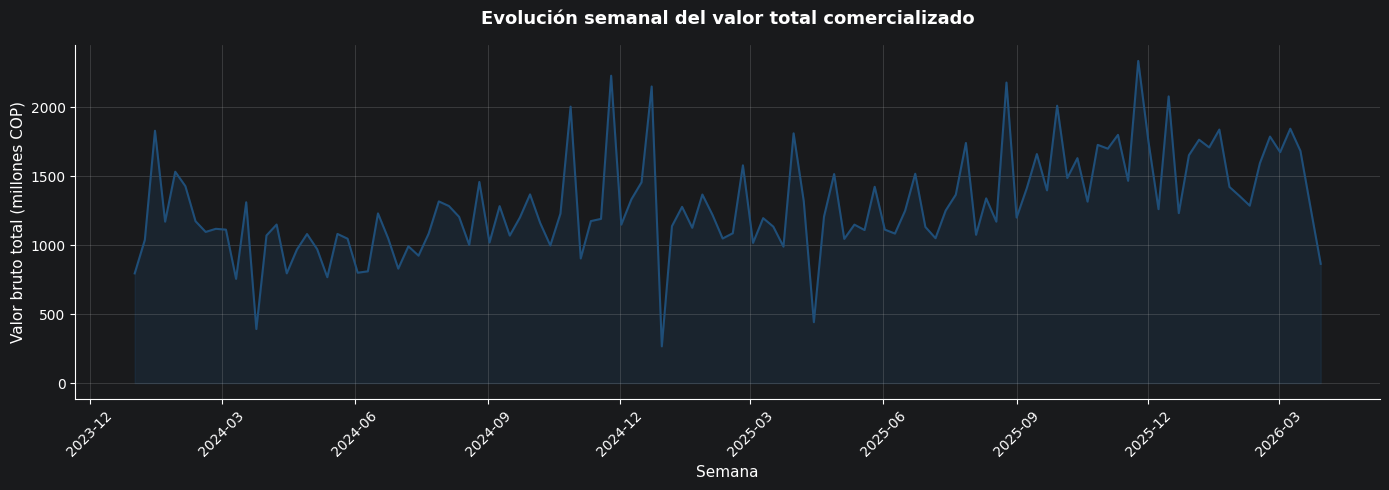


Valor total comercializado: $152,591,066,108 COP
Promedio semanal: $1,293,144,628 COP


In [4]:
# Serie semanal agregada
serie_valor = (
    ventas_semanales.groupby("fecha_inicio_semana")["valor_bruto_total"]
    .sum()
    .div(1_000_000)  # convertir a millones
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_valor.index, serie_valor.values,
        color=COLOR_PRIMARIO, linewidth=1.5)
ax.fill_between(serie_valor.index, serie_valor.values,
                alpha=0.2, color=COLOR_PRIMARIO)

ax.set_title("Evolución semanal del valor total comercializado", pad=15)
ax.set_xlabel("Semana")
ax.set_ylabel("Valor bruto total (millones COP)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
guardar(fig, "01_serie_valor_semanal")
plt.show()

print(f"\nValor total comercializado: ${serie_valor.sum() * 1_000_000:,.0f} COP")
print(f"Promedio semanal: ${serie_valor.mean() * 1_000_000:,.0f} COP")

### 1.2 Evolución semanal de unidades vendidas

  Guardado: reports/figures/02_serie_cantidad_semanal.png


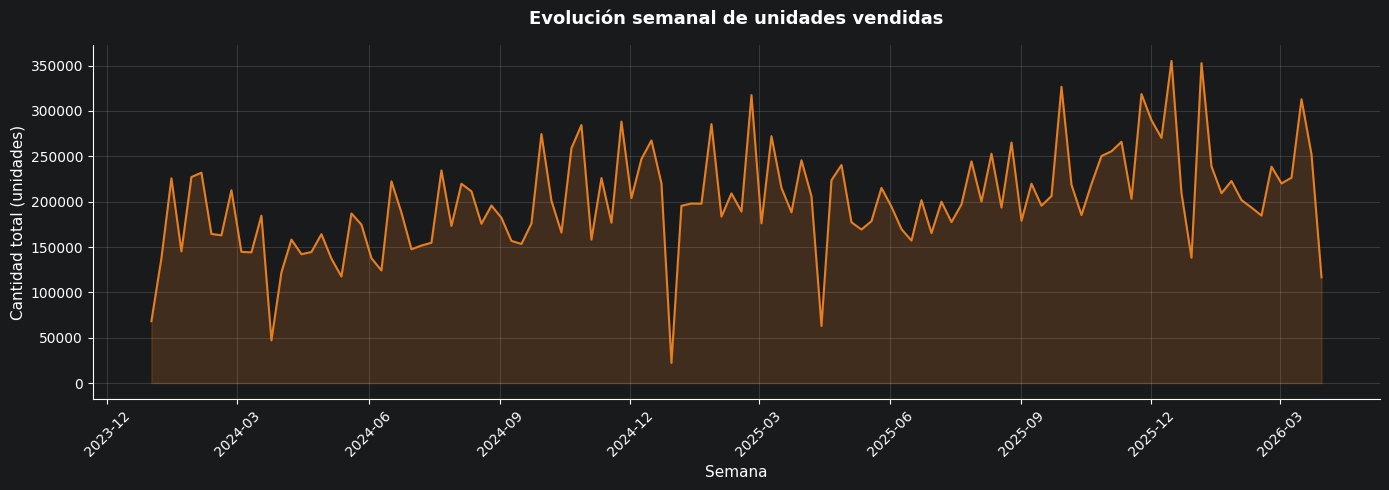

In [5]:
serie_cantidad = (
    ventas_semanales.groupby("fecha_inicio_semana")["cantidad_total"]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_cantidad.index, serie_cantidad.values,
        color=COLOR_SECUNDARIO, linewidth=1.5)
ax.fill_between(serie_cantidad.index, serie_cantidad.values,
                alpha=0.2, color=COLOR_SECUNDARIO)

ax.set_title("Evolución semanal de unidades vendidas", pad=15)
ax.set_xlabel("Semana")
ax.set_ylabel("Cantidad total (unidades)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
guardar(fig, "02_serie_cantidad_semanal")
plt.show()

### 1.3 Estacionalidad mensual

Heatmap año × mes para identificar patrones estacionales.

  Guardado: reports/figures/03_heatmap_estacionalidad.png


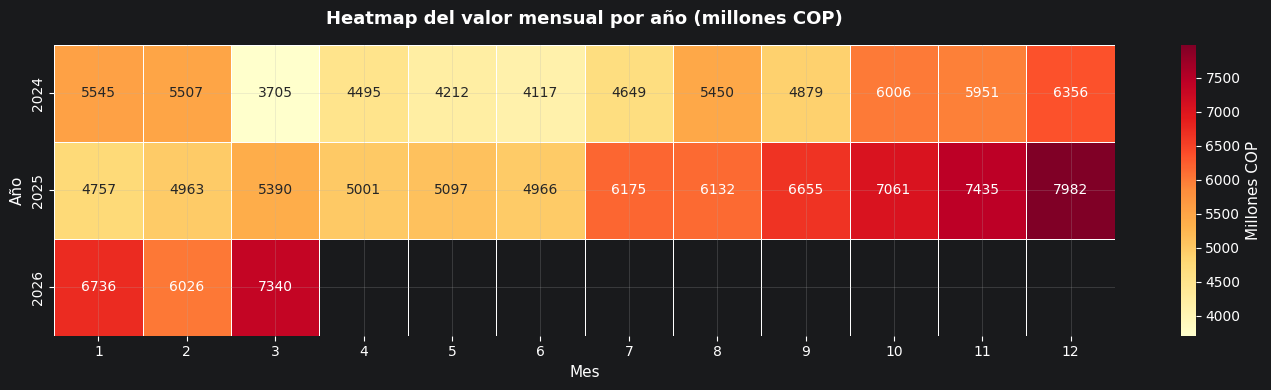


Nota: 2026 solo tiene Q1 completo (enero-marzo).
      2022 fue descartado del modelado pero se incluye aqui para contexto.


In [6]:
# Preparar datos para heatmap
ventas_crudas["anio"] = ventas_crudas["fecha"].dt.year
ventas_crudas["mes"] = ventas_crudas["fecha"].dt.month

heatmap_data = (
    ventas_crudas.groupby(["anio", "mes"])["valor_bruto"]
    .sum()
    .div(1_000_000)
    .unstack("mes")
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data,
            cmap="YlOrRd",
            annot=True, fmt=".0f",
            cbar_kws={"label": "Millones COP"},
            ax=ax,
            linewidths=0.5)

ax.set_title("Heatmap del valor mensual por año (millones COP)", pad=15)
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.tight_layout()
guardar(fig, "03_heatmap_estacionalidad")
plt.show()

print("\nNota: 2026 solo tiene Q1 completo (enero-marzo).")
print("      2022 fue descartado del modelado pero se incluye aqui para contexto.")

### 1.4 Distribución mensual del valor (boxplot)

Permite ver la variabilidad semanal dentro de cada mes.

  Guardado: reports/figures/04_boxplot_mensual.png


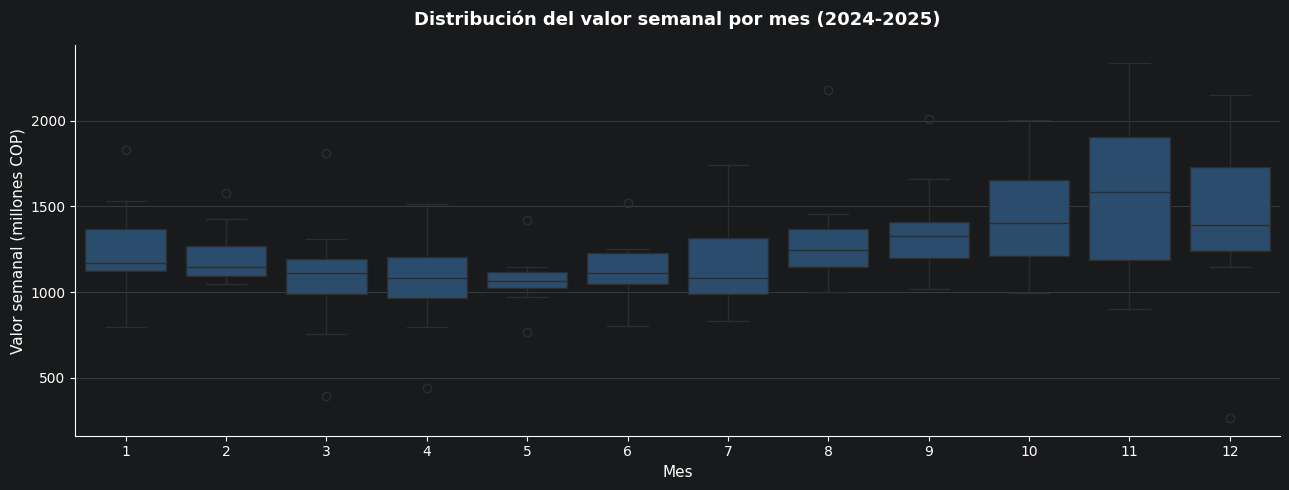

In [7]:
# Agregar columnas de tiempo a ventas_semanales
ventas_semanales["anio"] = ventas_semanales["fecha_inicio_semana"].dt.year
ventas_semanales["mes"] = ventas_semanales["fecha_inicio_semana"].dt.month

# Solo periodo de modelado (2024-2025) para no incluir 2026 incompleto
df_boxplot = ventas_semanales[ventas_semanales["anio"].isin([2024, 2025])]
agregado_semana = (
    df_boxplot.groupby(["fecha_inicio_semana", "mes"])["valor_bruto_total"]
    .sum()
    .div(1_000_000)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=agregado_semana, x="mes", y="valor_bruto_total",
            ax=ax, color=COLOR_PRIMARIO)
ax.set_title("Distribución del valor semanal por mes (2024-2025)", pad=15)
ax.set_xlabel("Mes")
ax.set_ylabel("Valor semanal (millones COP)")
plt.tight_layout()
guardar(fig, "04_boxplot_mensual")
plt.show()

## 2. Análisis por centro de operación

ConstruNorte opera 3 centros (`001`, `002`, `003`). Buscamos identificar diferencias estructurales entre ellos.

In [8]:
# Resumen por centro
resumen_centros = (
    ventas_semanales.groupby("centro_operacion")
    .agg(
        skus_distintos=("item", "nunique"),
        valor_total_millones=("valor_bruto_total", lambda s: s.sum() / 1_000_000),
        cantidad_total=("cantidad_total", "sum"),
        observaciones=("item", "count"),
    )
    .sort_values("valor_total_millones", ascending=False)
)
resumen_centros

,skus_distintos,valor_total_millones,cantidad_total,observaciones
centro_operacion,,,,
002,2860,"105,103.59","15,634,926.50",79432
001,2858,"39,374.26","7,487,352.75",87333
003,2100,"8,113.22","565,678.61",17435


  Guardado: reports/figures/05_centros_comparacion.png


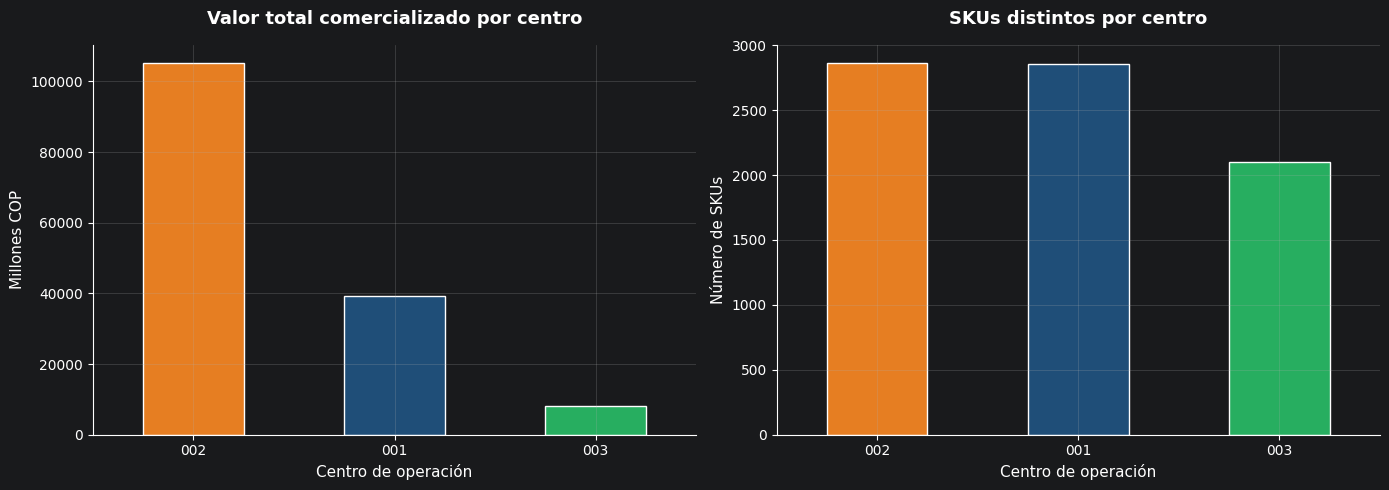

In [9]:
# Distribucion del valor por centro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot total
resumen_centros["valor_total_millones"].plot.bar(
    ax=axes[0],
    color=[PALETA_CENTROS[c] for c in resumen_centros.index],
    edgecolor="white",
)
axes[0].set_title("Valor total comercializado por centro", pad=15)
axes[0].set_xlabel("Centro de operación")
axes[0].set_ylabel("Millones COP")
axes[0].set_xticklabels(resumen_centros.index, rotation=0)

# Numero de SKUs
resumen_centros["skus_distintos"].plot.bar(
    ax=axes[1],
    color=[PALETA_CENTROS[c] for c in resumen_centros.index],
    edgecolor="white",
)
axes[1].set_title("SKUs distintos por centro", pad=15)
axes[1].set_xlabel("Centro de operación")
axes[1].set_ylabel("Número de SKUs")
axes[1].set_xticklabels(resumen_centros.index, rotation=0)

plt.tight_layout()
guardar(fig, "05_centros_comparacion")
plt.show()

  Guardado: reports/figures/06_evolucion_centros.png


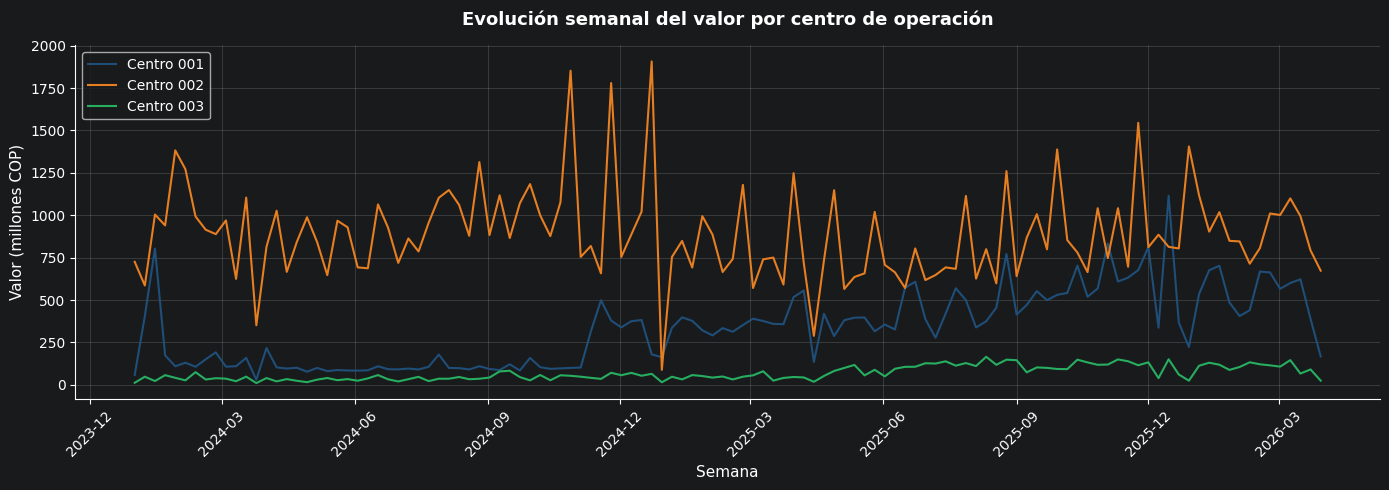

In [10]:
# Evolucion temporal comparada
serie_por_centro = (
    ventas_semanales.groupby(["fecha_inicio_semana", "centro_operacion"])["valor_bruto_total"]
    .sum()
    .div(1_000_000)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for centro in sorted(serie_por_centro["centro_operacion"].unique()):
    datos = serie_por_centro[serie_por_centro["centro_operacion"] == centro]
    ax.plot(datos["fecha_inicio_semana"], datos["valor_bruto_total"],
            label=f"Centro {centro}", color=PALETA_CENTROS[centro],
            linewidth=1.5)

ax.set_title("Evolución semanal del valor por centro de operación", pad=15)
ax.set_xlabel("Semana")
ax.set_ylabel("Valor (millones COP)")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
guardar(fig, "06_evolucion_centros")
plt.show()

## 3. Análisis por línea de producto

ConstruNorte clasifica sus productos en líneas N1 (familia) y N2 (subfamilia). Buscamos identificar las líneas con mayor peso en el negocio.

  Guardado: reports/figures/07_top_lineas_n1.png


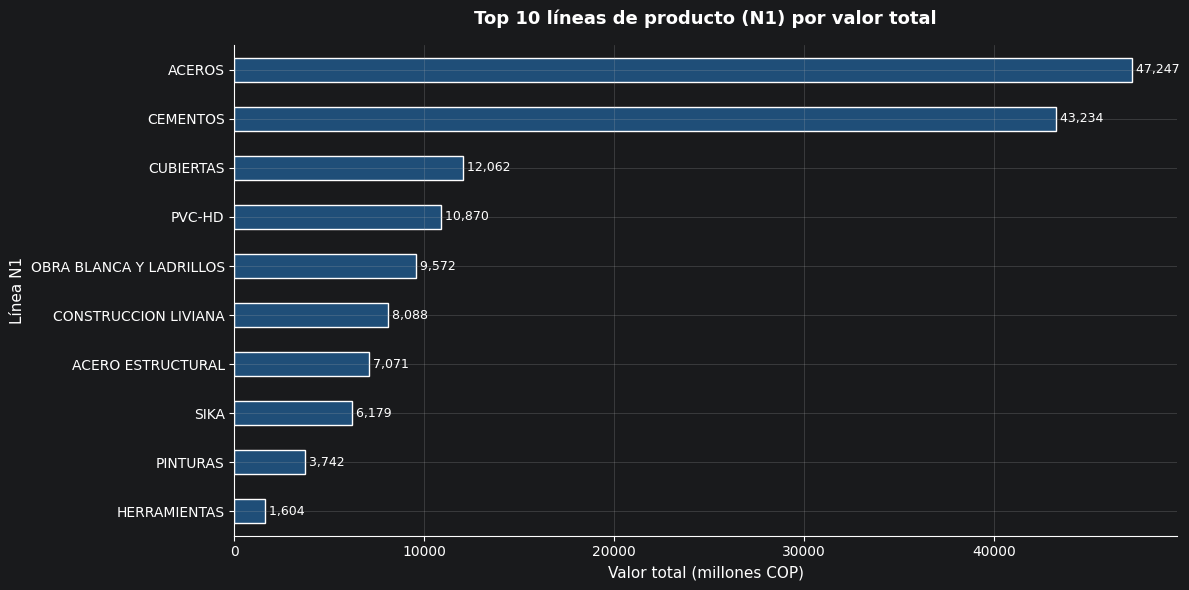

In [11]:
# Top 10 lineas N1 por valor
valor_por_linea_n1 = (
    ventas_semanales.merge(dim_producto[["item", "nombre_linea_n1"]], on="item", how="left")
    .groupby("nombre_linea_n1")["valor_bruto_total"]
    .sum()
    .div(1_000_000)
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
valor_por_linea_n1.plot.barh(ax=ax, color=COLOR_PRIMARIO, edgecolor="white")
ax.set_title("Top 10 líneas de producto (N1) por valor total", pad=15)
ax.set_xlabel("Valor total (millones COP)")
ax.set_ylabel("Línea N1")

# Anotaciones
for i, v in enumerate(valor_por_linea_n1.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
guardar(fig, "07_top_lineas_n1")
plt.show()

  Guardado: reports/figures/08_top_lineas_n2.png


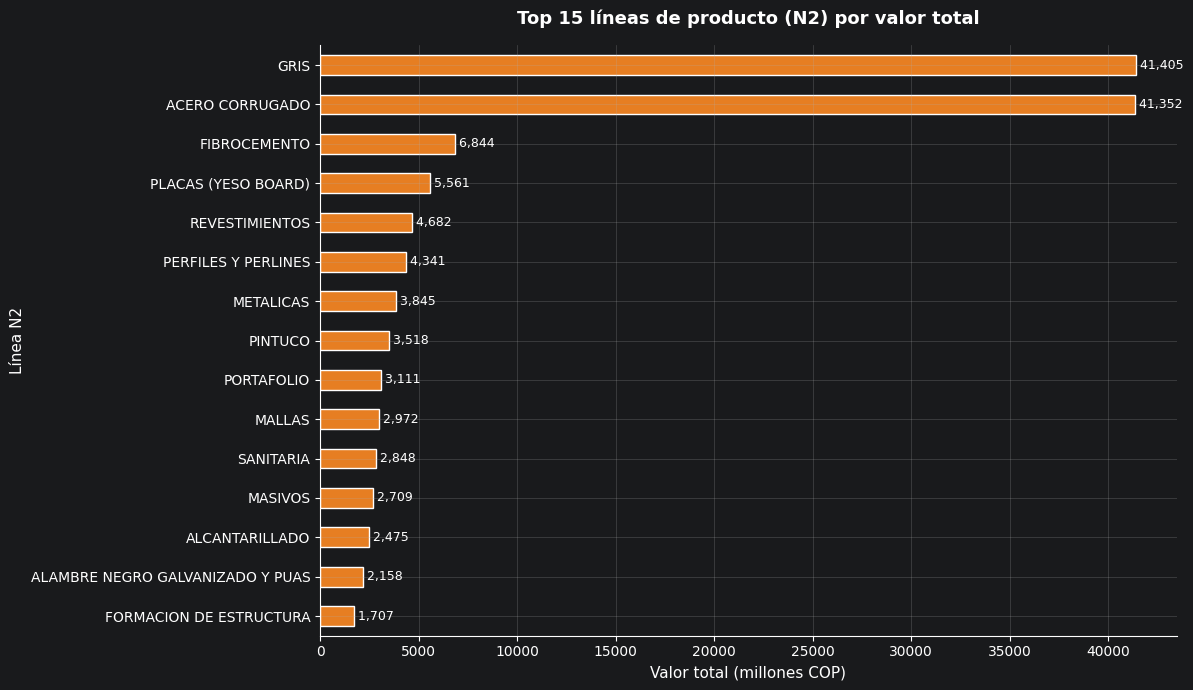

In [12]:
# Top 15 lineas N2
valor_por_linea_n2 = (
    ventas_semanales.merge(dim_producto[["item", "nombre_linea_n2"]], on="item", how="left")
    .groupby("nombre_linea_n2")["valor_bruto_total"]
    .sum()
    .div(1_000_000)
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
valor_por_linea_n2.plot.barh(ax=ax, color=COLOR_SECUNDARIO, edgecolor="white")
ax.set_title("Top 15 líneas de producto (N2) por valor total", pad=15)
ax.set_xlabel("Valor total (millones COP)")
ax.set_ylabel("Línea N2")

for i, v in enumerate(valor_por_linea_n2.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
guardar(fig, "08_top_lineas_n2")
plt.show()

  Guardado: reports/figures/09_heatmap_linea_centro.png


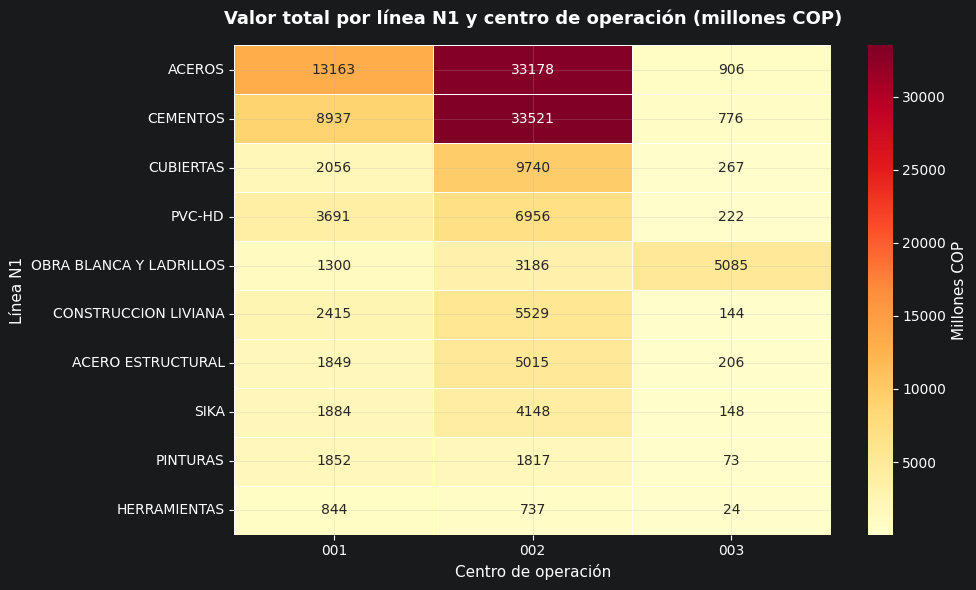

In [13]:
# Heatmap linea N1 x centro
matriz = (
    ventas_semanales.merge(dim_producto[["item", "nombre_linea_n1"]], on="item", how="left")
    .groupby(["nombre_linea_n1", "centro_operacion"])["valor_bruto_total"]
    .sum()
    .div(1_000_000)
    .unstack(fill_value=0)
)

# Top 10 lineas
top_lineas = matriz.sum(axis=1).sort_values(ascending=False).head(10).index
matriz_top = matriz.loc[top_lineas]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matriz_top, annot=True, fmt=".0f", cmap="YlOrRd",
            cbar_kws={"label": "Millones COP"}, linewidths=0.5, ax=ax)
ax.set_title("Valor total por línea N1 y centro de operación (millones COP)", pad=15)
ax.set_xlabel("Centro de operación")
ax.set_ylabel("Línea N1")
plt.tight_layout()
guardar(fig, "09_heatmap_linea_centro")
plt.show()

## 4. Análisis de SKUs

Caracterización del portafolio de productos a nivel individual.

### 4.1 Curva de Pareto (estática)

Visualiza la concentración del valor en los primeros SKUs.

  Guardado: reports/figures/10_pareto_estatico.png


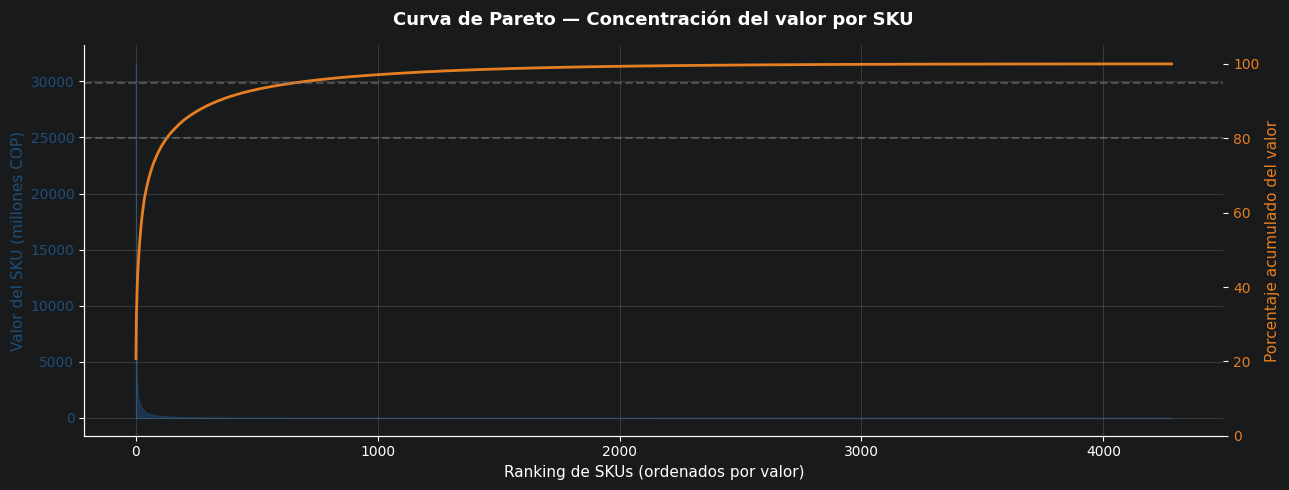


Concentracion del valor:
  80% del valor concentrado en   128 SKUs (3.0% del portafolio)
  95% del valor concentrado en   667 SKUs (15.6% del portafolio)


In [14]:
# Pareto
valor_por_sku = (
    ventas_semanales.groupby("item")["valor_bruto_total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)
valor_total = valor_por_sku.sum()
pct_acumulado = (valor_por_sku.cumsum() / valor_total * 100)

fig, ax1 = plt.subplots(figsize=(13, 5))
x = np.arange(1, len(valor_por_sku) + 1)

# Barras (azul)
ax1.fill_between(x, 0, valor_por_sku.values / 1_000_000,
                  color=COLOR_PRIMARIO, alpha=0.5, label="Valor por SKU")
ax1.set_xlabel("Ranking de SKUs (ordenados por valor)")
ax1.set_ylabel("Valor del SKU (millones COP)", color=COLOR_PRIMARIO)
ax1.tick_params(axis="y", labelcolor=COLOR_PRIMARIO)

# Linea acumulada (naranja)
ax2 = ax1.twinx()
ax2.plot(x, pct_acumulado, color=COLOR_SECUNDARIO, linewidth=2, label="% acumulado")
ax2.set_ylabel("Porcentaje acumulado del valor", color=COLOR_SECUNDARIO)
ax2.tick_params(axis="y", labelcolor=COLOR_SECUNDARIO)
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(95, color="gray", linestyle="--", alpha=0.5)
ax2.grid(False)

plt.title("Curva de Pareto — Concentración del valor por SKU", pad=15)
plt.tight_layout()
guardar(fig, "10_pareto_estatico")
plt.show()

# Tabla resumen
print("\nConcentracion del valor:")
for pct in [80, 95]:
    n_skus = (pct_acumulado <= pct).sum() + 1
    print(f"  {pct}% del valor concentrado en {n_skus:>5,} SKUs ({n_skus/len(valor_por_sku)*100:.1f}% del portafolio)")

### 4.2 Curva de Pareto interactiva (plotly)

Versión interactiva para usar en la sustentación. Permite hacer hover y zoom.

In [15]:
# Pareto interactivo con plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, y=valor_por_sku.values / 1_000_000,
    name="Valor por SKU (mill. COP)",
    fill="tozeroy",
    line=dict(color=COLOR_PRIMARIO),
    yaxis="y1",
    hovertemplate="<b>SKU ranking:</b> %{x}<br><b>Valor:</b> %{y:.2f} mill. COP<extra></extra>",
))

fig.add_trace(go.Scatter(
    x=x, y=pct_acumulado,
    name="% acumulado",
    line=dict(color=COLOR_SECUNDARIO, width=3),
    yaxis="y2",
    hovertemplate="<b>SKU ranking:</b> %{x}<br><b>Acumulado:</b> %{y:.2f}%<extra></extra>",
))

fig.update_layout(
    title="Curva de Pareto — Concentración del valor por SKU (interactivo)",
    xaxis=dict(title="Ranking de SKUs"),
    yaxis=dict(title="Valor (millones COP)", color=COLOR_PRIMARIO),
    yaxis2=dict(title="% acumulado", color=COLOR_SECUNDARIO,
                overlaying="y", side="right", range=[0, 105]),
    hovermode="x unified",
    template="plotly_white",
    height=500,
    legend=dict(x=0.7, y=0.5),
)

fig.add_hline(y=80, line_dash="dash", line_color="gray", yref="y2")
fig.add_hline(y=95, line_dash="dash", line_color="gray", yref="y2")

# Guardar como HTML interactivo
out_html = FIG_DIR / "10_pareto_interactivo.html"
fig.write_html(out_html)
print(f"  Guardado: {out_html.relative_to(ROOT)}")
fig.show()

  Guardado: reports/figures/10_pareto_interactivo.html


### 4.3 Top 20 SKUs por valor

  Guardado: reports/figures/11_top_20_skus.png


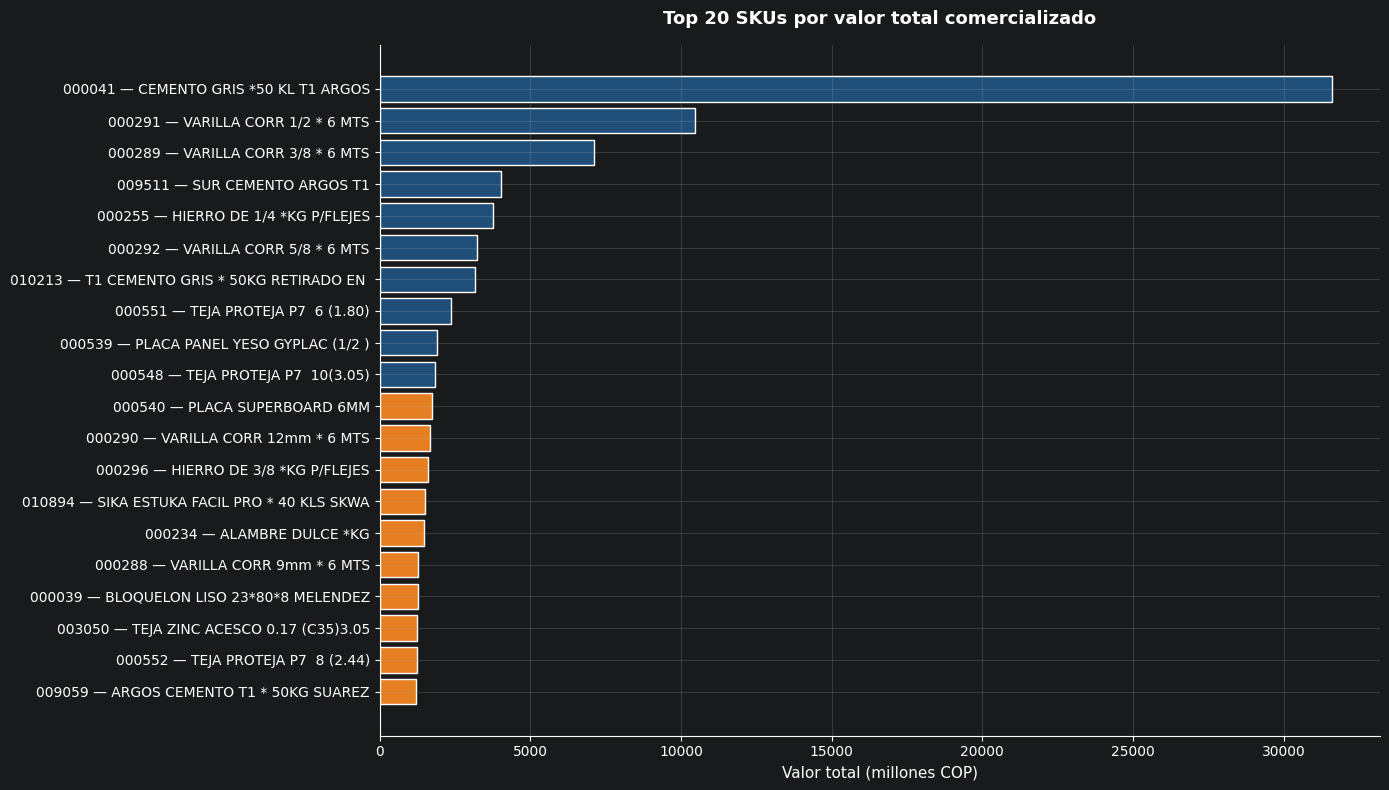

In [16]:
top20 = (
    ventas_semanales.groupby("item")["valor_bruto_total"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .merge(dim_producto[["item", "nombre_item", "nombre_linea_n1"]], on="item", how="left")
)
top20["etiqueta"] = top20["item"] + " — " + top20["nombre_item"].str[:35]

fig, ax = plt.subplots(figsize=(14, 8))
colores = [COLOR_PRIMARIO if i < 10 else COLOR_SECUNDARIO for i in range(20)]

ax.barh(top20["etiqueta"][::-1], top20["valor_bruto_total"][::-1] / 1_000_000,
        color=colores[::-1], edgecolor="white")

ax.set_title("Top 20 SKUs por valor total comercializado", pad=15)
ax.set_xlabel("Valor total (millones COP)")
ax.set_ylabel("")
plt.tight_layout()
guardar(fig, "11_top_20_skus")
plt.show()

### 4.4 Distribución de días de historia por SKU

¿Cuántos SKUs son nuevos vs. cuántos llevan mucho tiempo activos?

  Guardado: reports/figures/12_historia_skus.png


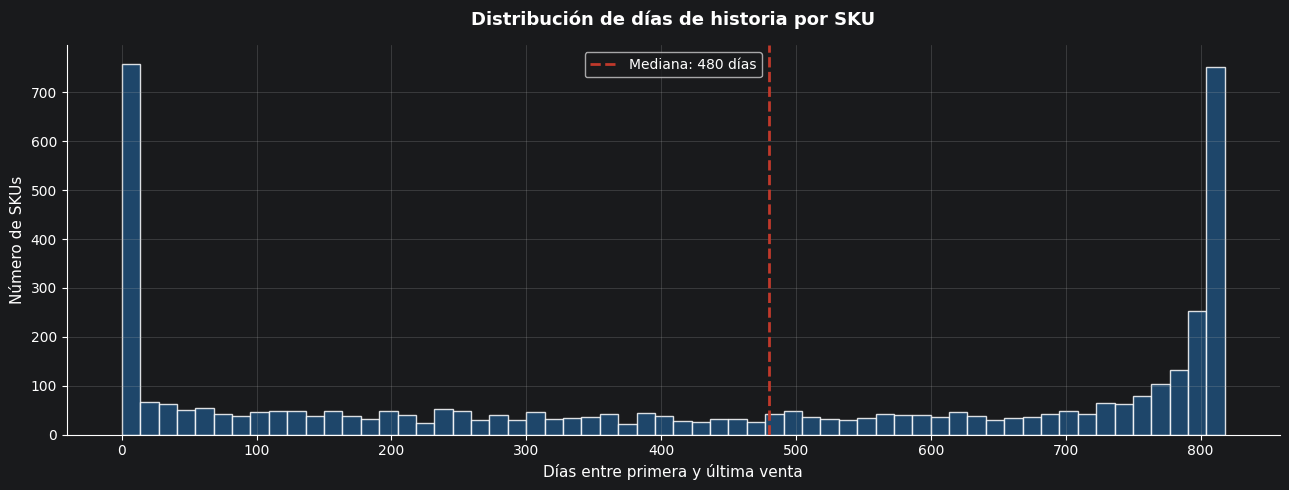


SKUs con menos de 30 dias de historia: 840
SKUs con mas de 365 dias de historia:    2,411


In [17]:
dim_producto["dias_historia"] = (
    dim_producto["fecha_ultima_venta"] - dim_producto["fecha_primera_venta"]
).dt.days

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(dim_producto["dias_historia"], bins=60,
        color=COLOR_PRIMARIO, edgecolor="white", alpha=0.85)
ax.axvline(dim_producto["dias_historia"].median(), color=COLOR_ROJO,
            linestyle="--", linewidth=2,
            label=f"Mediana: {dim_producto['dias_historia'].median():.0f} días")

ax.set_title("Distribución de días de historia por SKU", pad=15)
ax.set_xlabel("Días entre primera y última venta")
ax.set_ylabel("Número de SKUs")
ax.legend()
plt.tight_layout()
guardar(fig, "12_historia_skus")
plt.show()

print(f"\nSKUs con menos de 30 dias de historia: {(dim_producto['dias_historia'] < 30).sum():,}")
print(f"SKUs con mas de 365 dias de historia:    {(dim_producto['dias_historia'] >= 365).sum():,}")

### 4.5 Semanas con venta por SKU

¿Qué tan activos son los SKUs a lo largo del tiempo?

  Guardado: reports/figures/13_semanas_venta_sku.png


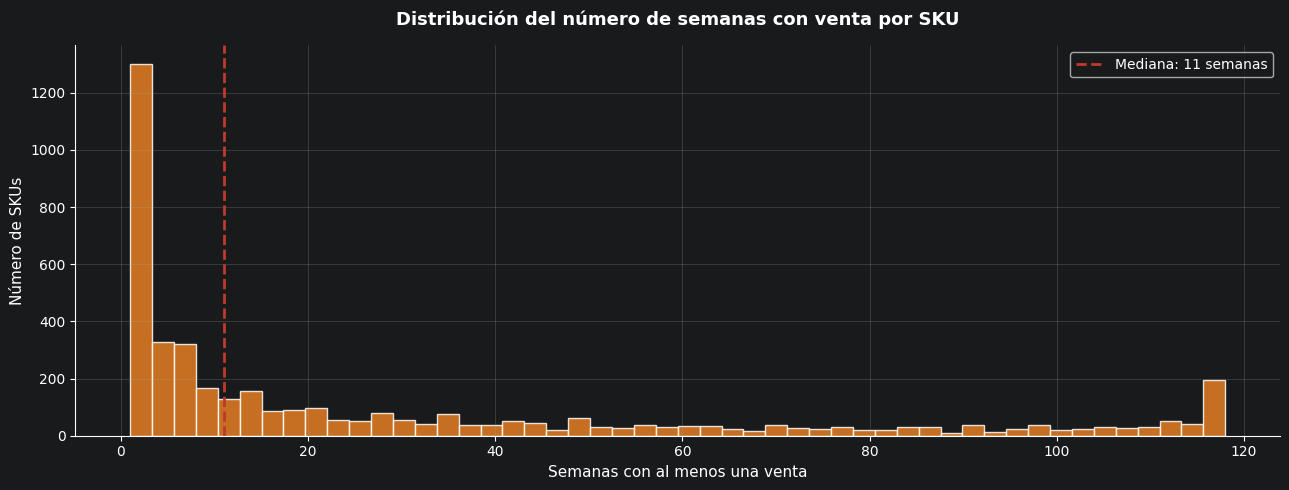


SKUs con < 5 semanas de venta:   1,483
SKUs con < 20 semanas de venta:  2,575
SKUs con > 80 semanas de venta:  621


In [18]:
semanas_con_venta = (
    ventas_semanales.groupby("item")["fecha_inicio_semana"].nunique()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(semanas_con_venta, bins=50,
        color=COLOR_SECUNDARIO, edgecolor="white", alpha=0.85)
ax.axvline(semanas_con_venta.median(), color=COLOR_ROJO,
            linestyle="--", linewidth=2,
            label=f"Mediana: {semanas_con_venta.median():.0f} semanas")

ax.set_title("Distribución del número de semanas con venta por SKU", pad=15)
ax.set_xlabel("Semanas con al menos una venta")
ax.set_ylabel("Número de SKUs")
ax.legend()
plt.tight_layout()
guardar(fig, "13_semanas_venta_sku")
plt.show()

print(f"\nSKUs con < 5 semanas de venta:   {(semanas_con_venta < 5).sum():,}")
print(f"SKUs con < 20 semanas de venta:  {(semanas_con_venta < 20).sum():,}")
print(f"SKUs con > 80 semanas de venta:  {(semanas_con_venta > 80).sum():,}")

## 5. Calidad de datos

Análisis de valores atípicos y posibles inconsistencias detectadas durante el perfilado.

### 5.1 Valores negativos en `valor_costo`

Detectados en el notebook 01. No afectan al modelo (la variable objetivo es `cantidad`), pero conviene documentarlos.

In [19]:
costos_negativos = ventas_crudas[ventas_crudas["valor_costo"] < 0]
print(f"Registros con valor_costo < 0: {len(costos_negativos):,} ({len(costos_negativos) / len(ventas_crudas) * 100:.4f}%)")

if len(costos_negativos) > 0:
    print(f"\nValor_costo minimo: {costos_negativos['valor_costo'].min():,.2f}")
    print(f"Distribucion por anio:")
    print(costos_negativos.groupby(costos_negativos["fecha"].dt.year).size())
    print("\nObservacion: estos registros corresponden probablemente a ajustes contables")
    print("retroactivos o notas credito. No se eliminan porque la variable objetivo")
    print("del modelo predictivo es 'cantidad', no 'valor_costo'.")

Registros con valor_costo < 0: 15 (0.0026%)

Valor_costo minimo: -10,971.38
Distribucion por anio:
fecha
2024    14
2025     1
dtype: int64

Observacion: estos registros corresponden probablemente a ajustes contables
retroactivos o notas credito. No se eliminan porque la variable objetivo
del modelo predictivo es 'cantidad', no 'valor_costo'.


### 5.2 Distribución del target — `cantidad_total`

Visualizamos la distribución en escala log para apreciar la cola larga típica de demanda de ferretería.

  Guardado: reports/figures/14_distribucion_target.png


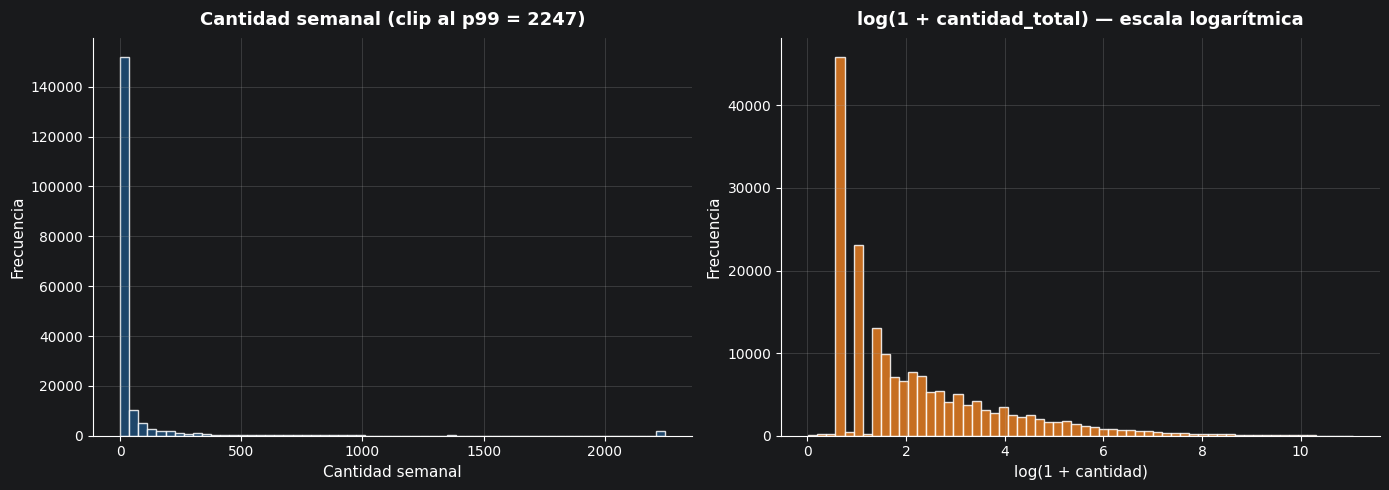


Estadisticas de cantidad_total:
                    count   mean      std  min  25%  50%   75%       max
cantidad_total 184,200.00 128.60 1,095.80 0.02 1.00 4.00 20.00 63,490.00

Conclusion: La distribucion es muy sesgada (cola larga).
Implicacion: considerar transformacion log para LightGBM/XGBoost.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala normal (clip al p99 para que se vea algo)
p99 = ventas_semanales["cantidad_total"].quantile(0.99)
axes[0].hist(ventas_semanales["cantidad_total"].clip(upper=p99),
              bins=60, color=COLOR_PRIMARIO, edgecolor="white", alpha=0.85)
axes[0].set_title(f"Cantidad semanal (clip al p99 = {p99:.0f})", pad=10)
axes[0].set_xlabel("Cantidad semanal")
axes[0].set_ylabel("Frecuencia")

# Escala log
positivos = ventas_semanales["cantidad_total"][ventas_semanales["cantidad_total"] > 0]
axes[1].hist(np.log1p(positivos), bins=60,
              color=COLOR_SECUNDARIO, edgecolor="white", alpha=0.85)
axes[1].set_title("log(1 + cantidad_total) — escala logarítmica", pad=10)
axes[1].set_xlabel("log(1 + cantidad)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
guardar(fig, "14_distribucion_target")
plt.show()

print(f"\nEstadisticas de cantidad_total:")
print(ventas_semanales["cantidad_total"].describe().to_frame().T)
print("\nConclusion: La distribucion es muy sesgada (cola larga).")
print("Implicacion: considerar transformacion log para LightGBM/XGBoost.")

## 6. Conclusiones del EDA

### 6.1 Hallazgos principales

**Temporales**
- La serie semanal de valor muestra estabilidad general con leve tendencia creciente en 2025.
- La estacionalidad mensual es moderada (no se observan ciclos drásticos como retail navideño).
- Los datos de 2026-Q1 muestran continuidad con el patrón histórico — apto como test extendido.

**Por centro**
- Los centros 001 y 002 manejan volúmenes comparables; el centro 003 es aproximadamente 10× más pequeño.
- Los tres centros muestran patrones temporales similares, lo que sugiere que **`centro_operacion` debe ser una variable categórica del modelo**, no un eje de modelos separados.

**Por línea de producto**
- Las líneas dominantes son **CEMENTOS, ACEROS y CUBIERTAS**, coherente con un negocio de materiales de construcción.
- La concentración por línea es elevada: pocas líneas explican la mayor parte del valor.

**Por SKU**
- **Pareto extremo:** 50 SKUs (1.2% del portafolio) concentran el 68% del valor; 100 SKUs (2.3%) concentran el 77%.
- Hay muchos SKUs con poca historia y pocas semanas de venta — la "larga cola" típica de ferretería.

**Calidad**
- Algunos registros tienen `valor_costo` negativo (ajustes contables). No afectan el target del modelo.
- La distribución de `cantidad_total` es muy sesgada (cola larga) — se recomienda transformación log en el modelado.

### 6.2 Decisiones que se derivan para el modelado

1. **No separar el modelo por centro:** usar `centro_operacion` como feature categórica.
2. **Considerar transformación log del target** en LightGBM/XGBoost (al menos como comparación).
3. **Estrategia diferenciada por clase ABC:**
    - Top SKUs (clase A): Prophet o LightGBM con features ricas.
    - SKUs medianos (clase B): LightGBM global.
    - SKUs de cola larga (clase C): baseline media móvil o modelo agregado.
4. **MAE como métrica principal:** interpretable en unidades. RMSE penaliza demasiado los SKUs con outliers grandes.
5. **Periodo 2026-Q1 como test extendido:** los patrones temporales son consistentes, así que es válido como evaluación fuera de muestra.
6. **Estacionalidad moderada:** las features cíclicas de mes/semana van a aportar señal, aunque no será el factor dominante.

### 6.3 Próximos pasos

- **Notebook 03 — Preparación**: feature engineering (lags, medias móviles, calendario, festivos), expansión de la serie con ceros, partición temporal.
- **Notebook 04 — ABC/XYZ**: formalización de la clasificación que ya se anticipa en este EDA.
- **Notebook 05+**: modelado predictivo.